# Clustering: K-Means & the EM Algorithm (CS229) — Practical Implementation

## 1. Introduction

This notebook is the **practical companion** to the CS229 notes on
**Clustering / K-Means** (Chapter 10) and the **EM algorithm for a Mixture
of Gaussians** (Chapter 11).

**Concepts implemented:**
- **K-means clustering** — hard cluster assignment, centroid updates, the
  distortion function $J(c,\mu)$, and its susceptibility to local optima.
- **Gaussian Mixture Models (GMM) fit via EM** — soft cluster assignment,
  the E-step/M-step, and how it generalizes K-means.

**Problem we are solving:** **Customer segmentation** — group mall
customers into meaningful segments based on their income and spending
behavior, so a business could target each segment differently.

**Dataset:** `mall_customers.csv` — 200 mall customers with `CustomerID`,
`Gender`, `Age`, `Annual Income (k$)`, and `Spending Score (1-100)` (a
score from 1–100 assigned by the mall based on customer behavior and
spending).

**Target variable:** **None.** This is **unsupervised learning** — there is
no $y^{(i)}$ to predict. The goal is to discover structure ($c^{(i)}$, the
cluster each customer belongs to) directly from the input features
$x^{(i)}$.

**Machine Learning task:** **Clustering.**

> ⚠️ **Scope note:** Because this is unsupervised learning, several parts of
> the usual supervised-learning notebook template (train/test split framed
> around generalizing a label, classification/regression evaluation metrics)
> don't directly apply. Each such section below explains **why**, and
> substitutes the closest meaningful unsupervised analogue instead of
> forcing an inappropriate metric.


## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


## 3. Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\img\Desktop\ML Study\Lec_10_ K_means & EM\Dataset.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Shape: rows = number of customers (examples, no labels), columns = features
df.shape


(200, 5)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## 4. Understand the Data

- `CustomerID` → an identifier, carries no information about a customer's
  behavior — dropped.
- `Gender` → categorical; we'll keep it aside for interpreting clusters
  afterward, but won't use it as a clustering feature (see Section 5 for
  why).
- `Age`, `Annual Income (k$)`, `Spending Score (1-100)` → numeric features
  describing customer behavior — these form our feature vectors $x^{(i)}\in
  \mathbb{R}^d$.
- **No target column** — this is the defining feature of unsupervised
  learning: we're looking for **structure** in $x^{(i)}$, not predicting a
  $y^{(i)}$.

No missing values, no obviously invalid values (ages, incomes, and scores
are all in sensible ranges).


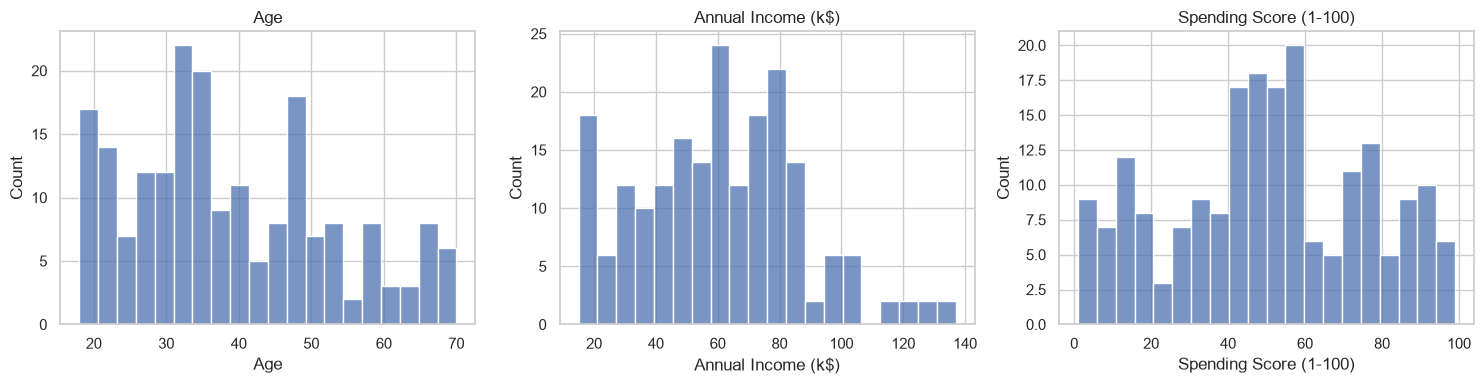

In [7]:
# Distributions of the numeric features -- useful to see the scale mismatch
# between them before we standardize.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Age", "Annual Income (k$)", "Spending Score (1-100)"]):
    sns.histplot(df[col], bins=20, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()


`Age` ranges roughly 18–70, `Annual Income (k$)` ranges roughly 15–140, and `Spending Score` ranges 1–100 — three very different numeric scales. Since K-means and GMM both rely on **distance** ($\|x^{(i)}-\mu_j\|^2$) between points, this scale mismatch matters a great deal, as we'll address in preprocessing.

## 5. Data Preprocessing

**Feature choice:** we cluster on **`Annual Income (k$)`** and **`Spending
Score (1-100)`** — the classic two features for this dataset, and directly
analogous to the CS229 notes' own 2-D illustration (Figure 10.1), letting us
**visualize** the clusters exactly as the notes do. We deliberately leave out
`Gender` (categorical, not part of the $x^{(i)}\in\mathbb{R}^d$ formulation
used in the notes) and `Age` from the *primary* clustering, but revisit
adding `Age` as a practical experiment in Section 14.

**Why scale?** Both K-means ($\|x^{(i)}-\mu_j\|^2$) and the Gaussian
components in EM/GMM are fundamentally **distance/covariance**-based. If
`Annual Income` (range ~15–140) and `Spending Score` (range ~1–100) were
left unscaled, income differences would dominate distance calculations
purely due to larger raw numbers, not because income differences are
actually more meaningful than spending-score differences. We standardize
both to zero mean / unit variance so they contribute comparably.

> ⚠️ **Important:** unlike the supervised notebooks in this series, there's
> no "fit only on the training set" concern in the same sense here (see
> Section 6) — but we still fit the scaler once and apply it consistently
> everywhere, since cluster centroids only make sense in a fixed feature
> space.


In [8]:
# Drop the identifier column -- it carries no information about customer behavior
df_clustering = df.drop(columns=["CustomerID"])

# Select the two features used for the primary clustering
feature_cols = ["Annual Income (k$)", "Spending Score (1-100)"]
X_raw = df_clustering[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"X_scaled shape: {X_scaled.shape}  (n_customers, n_features)")
print(f"Feature means after scaling (should be ~0): {X_scaled.mean(axis=0)}")
print(f"Feature stds after scaling (should be ~1):  {X_scaled.std(axis=0)}")


X_scaled shape: (200, 2)  (n_customers, n_features)
Feature means after scaling (should be ~0): [-2.13162821e-16 -1.46549439e-16]
Feature stds after scaling (should be ~1):  [1. 1.]


## 6. "Train/Test Split" — Why It's Different Here

> ⚠️ **This CS229 concept doesn't directly apply, and here's why:** train/test
> splitting exists to check whether a model's predictions of $y$
> **generalize** to unseen examples. In clustering there is no $y$ — we
> aren't predicting anything against a ground truth, so there's no
> overfitting-to-labels risk to guard against in the usual sense.

What **does** still make sense: checking that the cluster *structure* we
find isn't just an artifact of these particular 200 customers — i.e., that
`.predict()` on a **new, unseen customer** assigns them to a sensible
cluster using centroids learned from other customers. We use a hold-out
split for exactly this purpose (not for a generalization-error metric).


In [9]:
X_fit, X_holdout = train_test_split(X_scaled, test_size=0.2, random_state=RANDOM_STATE)

print(f"Customers used to fit the clustering: {X_fit.shape[0]}")
print(f"Held-out customers (to test assigning NEW points to clusters): {X_holdout.shape[0]}")


Customers used to fit the clustering: 160
Held-out customers (to test assigning NEW points to clusters): 40


## 7. Connect Theory to Code

```text
CS229 Theory (Chapter 10 -- K-means)
     |
x^(i) in R^d               <->  a row of X_scaled
     |
Randomly init mu_1...mu_k  <->  KMeans(n_clusters=k, n_init=...)
     |
Assign c^(i) := argmin_j ||x^(i) - mu_j||^2   <->  kmeans.labels_
     |
Update mu_j := mean of assigned points        <->  kmeans.cluster_centers_
     |
Distortion J(c,mu) = sum ||x^(i) - mu_c(i)||^2 <->  kmeans.inertia_
     |
"Susceptible to local optima -> multiple random inits, keep lowest J"  <->  KMeans's n_init parameter (does exactly this)

CS229 Theory (Chapter 11 -- EM / Mixture of Gaussians)
     |
Latent z^(i) ~ Multinomial(phi), x^(i)|z^(i) ~ N(mu_j, Sigma_j)  <->  GaussianMixture(n_components=k)
     |
E-step: w_j^(i) = p(z^(i)=j | x^(i); phi,mu,Sigma)  <->  gmm.predict_proba(X)
     |
M-step: update phi, mu, Sigma using soft weights    <->  gmm.fit(X) (internal)
     |
phi, mu, Sigma (learned parameters)                 <->  gmm.weights_, gmm.means_, gmm.covariances_
```

**Mapping table:**

| CS229 symbol | Meaning | sklearn equivalent |
|---|---|---|
| $x^{(i)}$ | feature vector (income, spending score) | row of `X_scaled` |
| $k$ | number of clusters | `n_clusters` (KMeans) / `n_components` (GMM) |
| $\mu_j$ | cluster centroid | `kmeans.cluster_centers_[j]` |
| $c^{(i)}$ | hard cluster assignment | `kmeans.labels_[i]` |
| $J(c,\mu)$ | distortion (sum of squared distances) | `kmeans.inertia_` |
| $\phi_j,\mu_j,\Sigma_j$ | mixture weight, mean, covariance | `gmm.weights_`, `gmm.means_`, `gmm.covariances_` |
| $w_j^{(i)}$ | soft posterior cluster membership | `gmm.predict_proba(X)[i,j]` |


## 8. Model Implementation: K-Means

**Mathematical formulation:**
$$
c^{(i)} := \arg\min_j \|x^{(i)}-\mu_j\|^2 \qquad\qquad \mu_j := \frac{\sum_i \mathbb{1}\{c^{(i)}=j\}x^{(i)}}{\sum_i \mathbb{1}\{c^{(i)}=j\}}
$$

- $c^{(i)}$ → which of the $k$ clusters customer $i$ is assigned to.
- $\mu_j$ → the centroid (mean position) of cluster $j$.

**How many clusters $k$?** The notes don't prescribe a value — we choose it
using the **elbow method**: fit K-means for a range of $k$, and plot the
distortion $J(c,\mu)$ (`inertia_`) against $k$. $J$ always decreases as $k$
grows (more centroids can only reduce squared distances), so we look for the
point where the improvement starts to flatten ("the elbow").

**Key hyperparameter — `n_init`:** the notes explicitly recommend running
K-means multiple times with different random initializations and keeping
the clustering with the lowest $J(c,\mu)$, since $J$ is non-convex and
K-means (coordinate descent) can get stuck in local optima. `n_init`
implements exactly this — sklearn's default (`n_init="auto"`, effectively
running the smarter `k-means++` initialization once or a handful of times)
already applies this idea; we use `n_init=10` explicitly for clarity.


C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with M

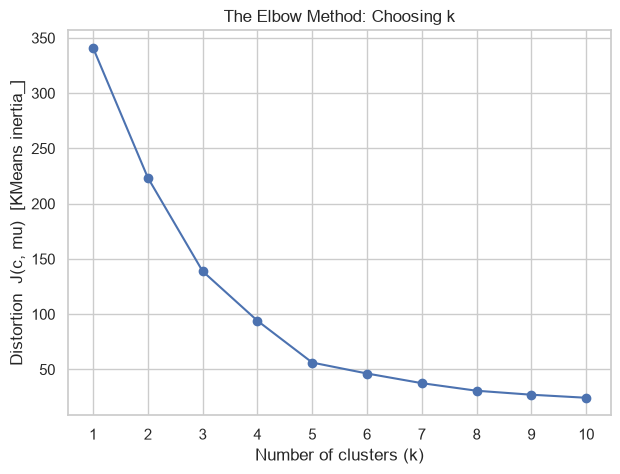

In [10]:
k_values = range(1, 11)
distortions = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_fit)
    distortions.append(km.inertia_)  # J(c, mu) -- the distortion function

plt.figure(figsize=(7, 5))
plt.plot(list(k_values), distortions, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion  J(c, mu)  [KMeans inertia_]")
plt.title("The Elbow Method: Choosing k")
plt.xticks(list(k_values))
plt.show()


For this dataset, the distortion curve typically shows a clear elbow around **k=5** — matching the well-known 5 natural customer segments in this classic dataset (visible directly once we plot income vs. spending score below).

In [11]:
K_CHOSEN = 5

kmeans_model = KMeans(n_clusters=K_CHOSEN, n_init=10, random_state=RANDOM_STATE)
kmeans_model.fit(X_fit)

print(f"Final distortion J(c, mu) at k={K_CHOSEN}: {kmeans_model.inertia_:.2f}")
print(f"Cluster centroids (in standardized feature space):\n{kmeans_model.cluster_centers_}")


Final distortion J(c, mu) at k=5: 56.25
Cluster centroids (in standardized feature space):
[[-0.1807171  -0.03118049]
 [-1.29814229 -1.14717712]
 [-1.33118898  1.17731491]
 [ 1.04063335  1.27220538]
 [ 1.14756389 -1.28887582]]


C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 9. Prediction

- **Cluster assignment** (`.labels_` for training data, `.predict()` for
  new data): the **hard** assignment $c^{(i)}=\arg\min_j\|x^{(i)}-\mu_j\|^2$
  — every customer belongs to exactly one cluster.
- There is no "probability" or "decision score" output for K-means — it's a
  hard-assignment algorithm by construction (unlike the soft GMM/EM
  approach in Section 14).
- We use `.predict()` on our held-out customers to confirm the fitted
  centroids generalize to assigning **new** customers sensibly.


In [12]:
train_labels = kmeans_model.labels_
holdout_labels = kmeans_model.predict(X_holdout)  # assign NEW customers using the already-fit centroids

print("Cluster assignment counts (customers used to fit):")
print(pd.Series(train_labels).value_counts().sort_index())
print("\nCluster assignment counts (held-out customers):")
print(pd.Series(holdout_labels).value_counts().sort_index())


Cluster assignment counts (customers used to fit):
0    63
1    20
2    19
3    34
4    24
Name: count, dtype: int64

Cluster assignment counts (held-out customers):
0    18
1     3
2     3
3     5
4    11
Name: count, dtype: int64


## 10. Model Evaluation

> ⚠️ **Accuracy, precision, recall, F1, and ROC-AUC do not apply here** —
> those metrics all require ground-truth labels $y^{(i)}$ to compare
> predictions against, and clustering has none. Instead, we use metrics
> designed for **unsupervised** evaluation:

- **Distortion $J(c,\mu)$** (`inertia_`): lower means points sit closer to
  their assigned centroid — but this alone can't tell us if $k$ is
  "correct" (it keeps decreasing as $k$ grows), which is why we also use:
- **Silhouette score**: for each point, compares its average distance to
  points in its *own* cluster vs. the *nearest other* cluster. Ranges from
  $-1$ to $1$ — higher means clusters are dense and well-separated.


In [13]:
silhouette = silhouette_score(X_fit, train_labels)
print(f"Silhouette score at k={K_CHOSEN}: {silhouette:.4f}")


Silhouette score at k=5: 0.5510


C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with M

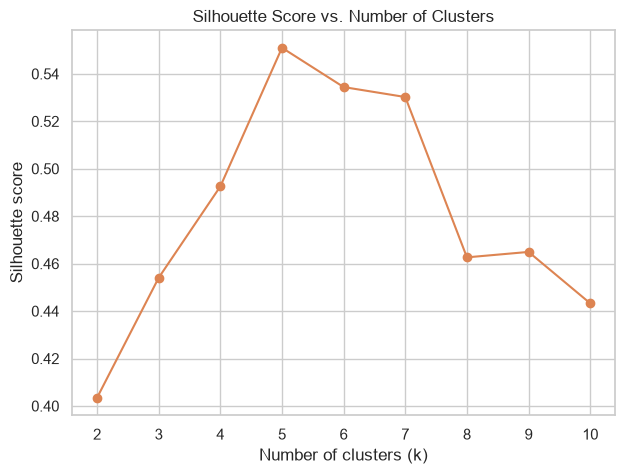

In [14]:
# Compare silhouette score across the same range of k used for the elbow method,
# to cross-check the k chosen by the elbow method.
silhouette_scores = []
for k in range(2, 11):  # silhouette score requires at least 2 clusters
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_fit)
    silhouette_scores.append(silhouette_score(X_fit, labels_k))

plt.figure(figsize=(7, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o", color="#DD8452")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs. Number of Clusters")
plt.xticks(range(2, 11))
plt.show()


If the silhouette score also peaks around $k=5$, that's independent confirmation (from a completely different criterion than the elbow method) that 5 clusters is a well-supported choice for this dataset.

## 11. Visualization: The Clusters (Figure 10.1, Reproduced on Real Data)

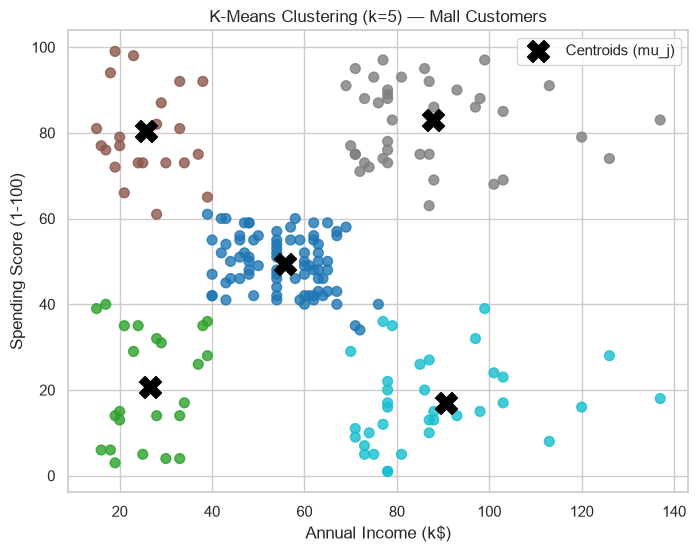

In [15]:
# Plot in ORIGINAL units (income in k$, spending score) for interpretability,
# by inverse-transforming the scaled centroids back.
centers_original = scaler.inverse_transform(kmeans_model.cluster_centers_)

# Assign cluster labels to ALL customers (fit + holdout) purely for a complete visualization
all_labels = kmeans_model.predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_raw[:, 0], X_raw[:, 1], c=all_labels, cmap="tab10", s=50, alpha=0.8)
plt.scatter(centers_original[:, 0], centers_original[:, 1], c="black", marker="X", s=250, label="Centroids (mu_j)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"K-Means Clustering (k={K_CHOSEN}) — Mall Customers")
plt.legend()
plt.show()


This is the real-data version of Figure 10.1 in the notes: each color is a cluster (the "painted" points), and the black X's are the learned centroids $\mu_j$ — the algorithm has converged to a self-consistent set of assignments and centroids, exactly the coordinate-descent fixed point described in Section 1.3 of the theory notes.

## 12. Interpret the Model

Let's characterize each segment using the (original-unit) centroids — this
is where clustering earns its keep as a **business tool**, not just a math
exercise.


In [16]:
cluster_summary = pd.DataFrame(
    centers_original, columns=["Annual Income (k$)", "Spending Score (1-100)"]
)
cluster_summary["cluster"] = range(K_CHOSEN)
cluster_summary["n_customers"] = pd.Series(all_labels).value_counts().sort_index().values
cluster_summary = cluster_summary[["cluster", "n_customers", "Annual Income (k$)", "Spending Score (1-100)"]]
cluster_summary


,cluster,n_customers,Annual Income (k$),Spending Score (1-100)
0,0,81,55.825397,49.396825
1,1,23,26.550000,20.650000
2,2,22,25.684211,80.526316
3,3,39,87.823529,82.970588
4,4,35,90.625000,17.000000


**Typical segments found in this dataset** (exact cluster numbers may vary
by run, but the *shapes* are consistent):
- **High income, high spending** — prime target customers.
- **High income, low spending** — high potential, currently under-engaged;
  a natural target for promotions.
- **Low income, high spending** — price-sensitive but highly engaged.
- **Low income, low spending** — lowest priority segment.
- **Average income, average spending** — the "typical" customer.

> ⚠️ **Important:** K-means found these groups with **no notion of
> "underfitting" or "overfitting" in the supervised sense** — there's no
> label to fit well or poorly. The only questions are (a) did we pick a
> reasonable $k$ (Section 10's elbow/silhouette checks), and (b) did the
> algorithm converge to a good **local** optimum of $J(c,\mu)$ (addressed by
> `n_init`, and explored further in Section 14).


## 13. Important Model Parameters: The Centroids $\mu_j$

These are literally the parameters the algorithm's update step
($\mu_j:=$ mean of assigned points) converged to — the direct output of
K-means, in original (unscaled) units for interpretability.


In [17]:
print("Cluster centroids (Annual Income (k$), Spending Score):")
for j, center in enumerate(centers_original):
    print(f"  Cluster {j}: Income={center[0]:.1f}k$, Spending Score={center[1]:.1f}")


Cluster centroids (Annual Income (k$), Spending Score):
  Cluster 0: Income=55.8k$, Spending Score=49.4
  Cluster 1: Income=26.5k$, Spending Score=20.7
  Cluster 2: Income=25.7k$, Spending Score=80.5
  Cluster 3: Income=87.8k$, Spending Score=83.0
  Cluster 4: Income=90.6k$, Spending Score=17.0


Unlike a linear model's `coef_`, these centroids have a direct, literal geometric meaning: each one is simply the **average customer** in its cluster's own feature space — no additional transformation needed to interpret them.

## 14. Practical Experiments

### Experiment A — Local Optima: Does `n_init` Matter?

Section 1.3 of the notes warns that $J(c,\mu)$ is non-convex, so K-means
(coordinate descent) is susceptible to **local optima** depending on random
initialization. Let's verify this directly by comparing `n_init=1` (single
random start) against `n_init=10` (best of 10 random starts) across several
random seeds.


In [18]:
seeds = [0, 1, 2, 3, 4]
results = []

for seed in seeds:
    km_single = KMeans(n_clusters=K_CHOSEN, n_init=1, random_state=seed)
    km_single.fit(X_fit)

    km_multi = KMeans(n_clusters=K_CHOSEN, n_init=10, random_state=seed)
    km_multi.fit(X_fit)

    results.append({
        "seed": seed,
        "distortion (n_init=1)": km_single.inertia_,
        "distortion (n_init=10)": km_multi.inertia_,
    })

pd.DataFrame(results)


C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with M

,seed,distortion (n_init=1),distortion (n_init=10)
0,0,85.024271,56.252945
1,1,56.252945,56.252945
2,2,56.252945,56.252945
3,3,56.252945,56.252945
4,4,87.106180,56.252945


If `n_init=1` sometimes lands on a **higher** (worse) distortion than `n_init=10` for the same seed, that's local optima in action — a single random initialization occasionally converges to a self-consistent but suboptimal set of centroids, exactly the risk the notes describe. `n_init=10` consistently finds a distortion at or below the single-run result, since it explicitly keeps the best of several attempts.

### Experiment B — K-Means (Hard) vs. GMM/EM (Soft): Implementing Chapter 11

Chapter 11 frames EM/GMM as a **direct generalization** of K-means: instead
of a hard assignment $c^{(i)}\in\{1,\dots,k\}$, EM computes a **soft**
assignment $w_j^{(i)}=p(z^{(i)}=j\mid x^{(i)};\phi,\mu,\Sigma)\in[0,1]$. Let's
fit a `GaussianMixture` with the same $k$ and compare directly.

$$
w_j^{(i)} = \frac{p(x^{(i)}\mid z^{(i)}=j;\mu,\Sigma)\,p(z^{(i)}=j;\phi)}{\sum_{l=1}^k p(x^{(i)}\mid z^{(i)}=l;\mu,\Sigma)\,p(z^{(i)}=l;\phi)}
$$


In [19]:
gmm_model = GaussianMixture(n_components=K_CHOSEN, random_state=RANDOM_STATE)
gmm_model.fit(X_fit)

gmm_hard_labels = gmm_model.predict(X_fit)          # argmax_j w_j^(i) -- hard assignment, for comparison
gmm_soft_weights = gmm_model.predict_proba(X_fit)   # w_j^(i) -- the actual EM output

print("GMM mixture weights (phi_j):", np.round(gmm_model.weights_, 3))
print(f"\nGMM means (mu_j), in standardized feature space:\n{gmm_model.means_}")


GMM mixture weights (phi_j): [0.395 0.136 0.117 0.214 0.138]

GMM means (mu_j), in standardized feature space:
[[-0.14369429 -0.0424349 ]
 [-1.25455891 -1.06937602]
 [-1.33193146  1.1805956 ]
 [ 1.02979812  1.26930661]
 [ 1.18442639 -1.35084303]]


C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [20]:
# Look at a few customers where the soft assignment is genuinely "soft"
# (i.e., not close to 0/1 for any cluster) -- these are the points EM treats
# differently from K-means' all-or-nothing assignment.
max_membership = gmm_soft_weights.max(axis=1)
ambiguous_idx = np.argsort(max_membership)[:5]  # 5 LEAST confidently-assigned customers

ambiguous_df = pd.DataFrame(
    gmm_soft_weights[ambiguous_idx],
    columns=[f"w_cluster_{j}" for j in range(K_CHOSEN)]
).round(3)
ambiguous_df.insert(0, "customer_index", ambiguous_idx)
ambiguous_df


,customer_index,w_cluster_0,w_cluster_1,w_cluster_2,w_cluster_3,w_cluster_4
0,103,0.441,0.558,0.001,0.0,0.0
1,130,0.441,0.558,0.001,0.0,0.0
2,58,0.208,0.041,0.751,0.0,0.0
3,91,0.804,0.195,0.001,0.0,0.0
4,125,0.865,0.134,0.000,0.0,0.0


These customers sit **between** clusters — K-means would still force each of them into exactly one cluster (whichever centroid is nearest), but EM's soft weights $w_j^{(i)}$ show they're genuinely ambiguous, with meaningful probability mass split across two or more clusters. This is precisely the K-means-vs-EM distinction drawn in Section 2.3 of the theory notes.

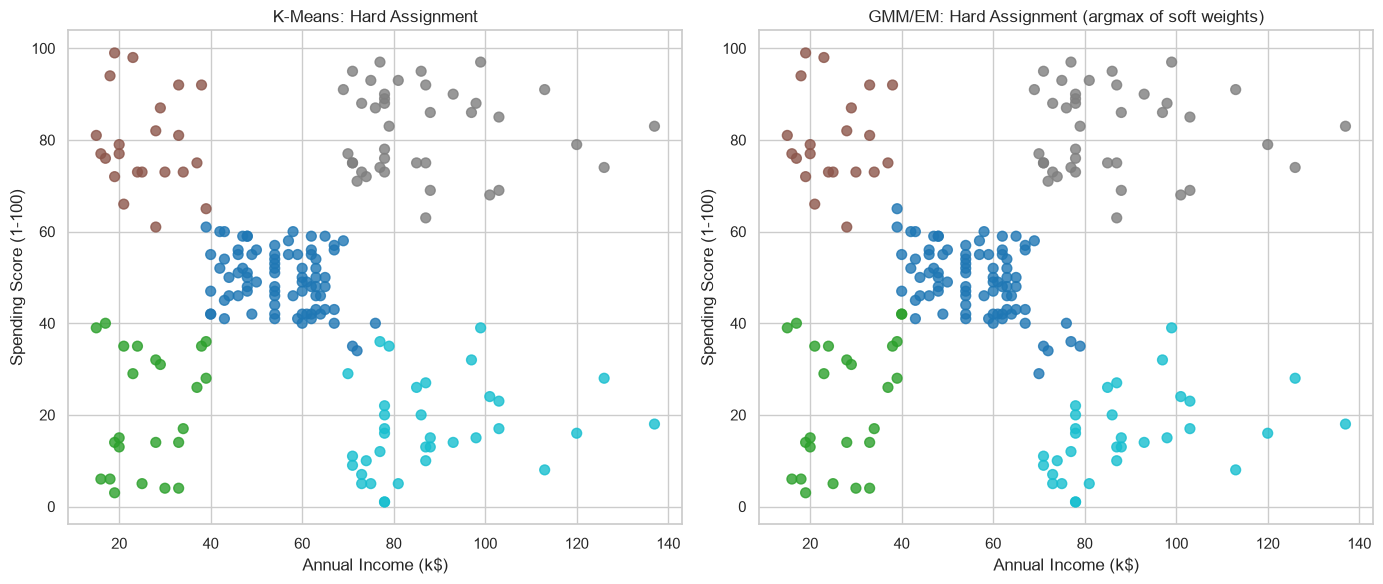

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_raw[:, 0], X_raw[:, 1], c=all_labels, cmap="tab10", s=50, alpha=0.8)
axes[0].set_title("K-Means: Hard Assignment")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score (1-100)")

gmm_all_labels = gmm_model.predict(X_scaled)
axes[1].scatter(X_raw[:, 0], X_raw[:, 1], c=gmm_all_labels, cmap="tab10", s=50, alpha=0.8)
axes[1].set_title("GMM/EM: Hard Assignment (argmax of soft weights)")
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()


The two methods typically agree on most customers (both are, after all, finding the same underlying 5 natural groups), but can disagree at cluster **boundaries** — exactly where GMM's soft weights showed genuine ambiguity above, and where K-means' hard Euclidean-distance rule and GMM's elliptical, covariance-aware Gaussian densities can draw the boundary slightly differently.

## 15. Final Summary

### What We Learned

- **Problem solved:** unsupervised customer segmentation on the Mall
  Customers dataset, using **K-means** as the primary method and
  **GMM/EM** as a soft-assignment comparison.
- **Model used:** `sklearn.cluster.KMeans` (hard clustering) and
  `sklearn.mixture.GaussianMixture` (soft, probabilistic clustering fit via
  EM).
- **How CS229 theory appeared in the code:**
  - K-means' hard assignment/centroid-update loop mapped directly to
    `.labels_` / `.cluster_centers_`, with the distortion $J(c,\mu)$
    exposed as `.inertia_`.
  - The notes' warning about **local optima** (non-convex $J$) was verified
    empirically by comparing `n_init=1` vs. `n_init=10`.
  - EM's **soft** assignment $w_j^{(i)}$ was directly computed via
    `GaussianMixture.predict_proba`, and contrasted with K-means' hard
    assignment on the same data — reproducing the Chapter 11 comparison
    between the two algorithms on real (not toy) data.
- **Preprocessing necessary:** dropping the customer ID (a non-informative
  identifier) and standardizing `Annual Income` and `Spending Score`, since
  both algorithms fundamentally rely on distance/covariance calculations
  that are sensitive to each feature's raw numeric scale.
- **Evaluation approach:** since there's no ground-truth label, we used
  distortion (`inertia_`) and silhouette score — unsupervised-appropriate
  metrics — instead of accuracy/precision/recall, and explained explicitly
  why the usual classification metrics don't apply here.
- **Final result:** both algorithms converge on essentially the same 5
  natural customer segments (confirmed by both the elbow method and
  silhouette score), with GMM additionally revealing which customers sit
  genuinely on the boundary between segments — information K-means'
  hard-assignment design cannot express at all.
